In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [2]:
#file_path = r"cleaned_dataset.csv"
file_path = r"cleaned_dataset_without_criticalcolumns.csv"

df = pd.read_csv(file_path)

In [3]:
features = [col for col in df.columns if col not in ['ID', 'Choice']]
X = df[features]
y = df['Choice']

#X = X.fillna(X.median(numeric_only=True))
#X = X.dropna(axis=1, how='all')

mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled_all = scaler.fit_transform(X)

print("\nGlobal Neural Network (MLP)")
model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=1000, early_stopping=True, random_state=42)

cv_scores = cross_val_score(model, X_scaled_all, y, cv=5, scoring='accuracy')
print("\nCross-Validation")
print(f"five-folder Accuracy: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f} ")

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n Test Set Evaluation")
print(f"Accuracy: {acc:.4f}")
print(f" Macro F1: {macro_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)


Global Neural Network (MLP)

Cross-Validation
five-folder Accuracy: [0.81460674 0.8079096  0.8079096  0.78531073 0.74576271]
Mean Accuracy: 0.7923
Standard Deviation: 0.0253 

 Test Set Evaluation
Accuracy: 0.7191
 Macro F1: 0.4332

Classification Report
              precision    recall  f1-score   support

         0.0       0.68      0.38      0.48        56
         1.0       0.73      0.93      0.82       115
         2.0       0.00      0.00      0.00         7

    accuracy                           0.72       178
   macro avg       0.47      0.44      0.43       178
weighted avg       0.68      0.72      0.68       178



c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\31628\anaconda31\envs\SEN122A\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

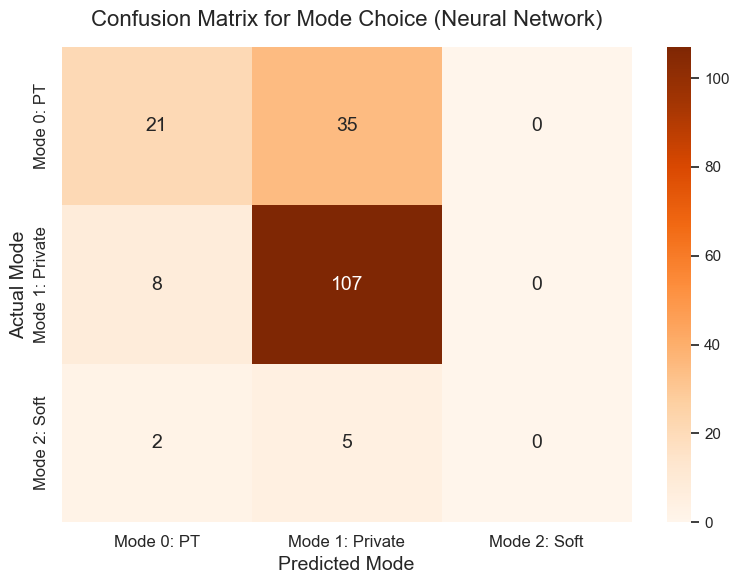

In [4]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                 xticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'], 
                 yticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'],
                 annot_kws={"size": 14}) 

plt.title('Confusion Matrix for Mode Choice (Neural Network)', fontsize=16, pad=15)
plt.xlabel('Predicted Mode', fontsize=14)
plt.ylabel('Actual Mode', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()